# 🔍 ML-Driven Data Observability System
### Final Year Project — Ecommerce Sales Data

**Tech Stack:** Python · MySQL · Power BI · APScheduler · Isolation Forest · Prophet

---
**Run cells top-to-bottom. Each section is self-contained.**

## 📦 CELL 1 — Install Required Libraries
> Run this ONCE. Restart kernel after installing.

In [3]:

import subprocess, sys

packages = [
    'pandas',
    'numpy',
    'scipy',
    'scikit-learn',
    'mysql-connector-python',
    'APScheduler',
    'prophet',
    'matplotlib',
    'seaborn',
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\n✅ All packages installed. Restart the kernel now (Kernel → Restart).')

Installing pandas...
Installing numpy...
Installing scipy...
Installing scikit-learn...
Installing mysql-connector-python...
Installing APScheduler...
Installing prophet...
Installing matplotlib...
Installing seaborn...

✅ All packages installed. Restart the kernel now (Kernel → Restart).


## ⚙️ CELL 2 — Configuration & Imports

In [4]:
import os, sys, warnings
warnings.filterwarnings('ignore')


PROJECT_ROOT = PROJECT_ROOT = r"E:\data science\pooject\data_observability_project\data_observability"  
sys.path.insert(0, PROJECT_ROOT)

CSV_PATH      = os.path.join(PROJECT_ROOT, 'data', 'Ecommerce_Sales_Data_2024_2025.csv')
SNAPSHOTS_DIR = os.path.join(PROJECT_ROOT, 'data', 'snapshots')
MODEL_PATH    = os.path.join(PROJECT_ROOT, 'ml_anomaly', 'saved_model.pkl')
LOG_DIR       = os.path.join(PROJECT_ROOT, 'logs')


DB_CONFIG = {
    'host':     'localhost',
    'port':     3306,
    'user':     'root',
    'password': 'Siva123',   # ← CHANGE THIS
    'database': 'data_observability'
}

print('✅ Configuration set.')
print(f'   Project root : {PROJECT_ROOT}')
print(f'   CSV path     : {CSV_PATH}')
print(f'   Snapshots    : {SNAPSHOTS_DIR}')

✅ Configuration set.
   Project root : E:\data science\pooject\data_observability_project\data_observability
   CSV path     : E:\data science\pooject\data_observability_project\data_observability\data\Ecommerce_Sales_Data_2024_2025.csv
   Snapshots    : E:\data science\pooject\data_observability_project\data_observability\data\snapshots


## 🗄️ CELL 3 — MySQL Database Setup
> Creates the `data_observability` database and `metrics_history` table.

In [5]:
import mysql.connector


init_cfg = {k: v for k, v in DB_CONFIG.items() if k != 'database'}
conn = mysql.connector.connect(**init_cfg)
cur  = conn.cursor()
cur.execute('CREATE DATABASE IF NOT EXISTS data_observability;')
print('✅ Database created.')


cur.execute('USE data_observability;')
cur.execute('''
CREATE TABLE IF NOT EXISTS metrics_history (
    id                 INT AUTO_INCREMENT PRIMARY KEY,
    dataset_name       VARCHAR(100)  NOT NULL,
    timestamp          DATETIME      NOT NULL,
    row_count          INT           NOT NULL,
    null_percentage    DECIMAL(6,4)  NOT NULL DEFAULT 0,
    duplicate_count    INT           NOT NULL DEFAULT 0,
    quality_score      DECIMAL(6,2)  NOT NULL DEFAULT 0,
    anomaly_flag       TINYINT(1)    NOT NULL DEFAULT 0,
    drift_score        DECIMAL(8,4)  NOT NULL DEFAULT 0,
    outlier_count      INT           NOT NULL DEFAULT 0,
    volume_change_pct  DECIMAL(8,2)  NOT NULL DEFAULT 0,
    max_skewness       DECIMAL(8,4)  NOT NULL DEFAULT 0,
    entropy_delta      DECIMAL(8,4)  NOT NULL DEFAULT 0,
    correlation_drift  DECIMAL(8,4)  NOT NULL DEFAULT 0,
    checks_passed      INT           NOT NULL DEFAULT 0,
    checks_failed      INT           NOT NULL DEFAULT 0,
    total_checks       INT           NOT NULL DEFAULT 0,
    created_at         DATETIME      DEFAULT CURRENT_TIMESTAMP
) ENGINE=InnoDB;
''')
conn.commit()
cur.close()
conn.close()
print('✅ Table metrics_history created.')
print('\nYou can now see this in MySQL Workbench under: data_observability → metrics_history')

✅ Database created.
✅ Table metrics_history created.

You can now see this in MySQL Workbench under: data_observability → metrics_history


## 📁 CELL 4 — Data Ingestion: Simulate 10 Daily Snapshots

In [6]:
from ingestion.data_ingestion import simulate_daily_snapshots, load_latest_snapshot, load_previous_snapshot


snapshot_paths = simulate_daily_snapshots(
    source_filepath = CSV_PATH,
    snapshots_dir   = SNAPSHOTS_DIR,
    num_days        = 10,
    inject_anomalies= True
)

print(f'\n✅ Created {len(snapshot_paths)} snapshots:')
for p in snapshot_paths:
    print(f'   {os.path.basename(p)}')

2026-04-11 20:16:12,915 | INFO | Loaded 'E:\data science\pooject\data_observability_project\data_observability\data\Ecommerce_Sales_Data_2024_2025.csv' → 5000 rows × 14 cols
2026-04-11 20:16:12,921 | INFO | Added ingestion_timestamp = 2026-04-01 20:16:12
2026-04-11 20:16:12,926 | INFO | Saved snapshot: E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-01.csv (441 rows)
2026-04-11 20:16:12,928 | INFO | Added ingestion_timestamp = 2026-04-02 20:16:12
2026-04-11 20:16:12,931 | INFO | Saved snapshot: E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-02.csv (405 rows)
2026-04-11 20:16:12,933 | INFO | Added ingestion_timestamp = 2026-04-03 20:16:12
2026-04-11 20:16:12,937 | INFO | Saved snapshot: E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-03.csv (577 rows)
2026-04-11 20:16:12,940 | INFO | Added ingestion_timestamp = 2026-04-04 20:1


✅ Created 10 snapshots:
   snapshot_2026-04-01.csv
   snapshot_2026-04-02.csv
   snapshot_2026-04-03.csv
   snapshot_2026-04-04.csv
   snapshot_2026-04-05.csv
   snapshot_2026-04-06.csv
   snapshot_2026-04-07.csv
   snapshot_2026-04-08.csv
   snapshot_2026-04-09.csv
   snapshot_2026-04-10.csv


## 🔍 CELL 5 — Run All 21 Quality Checks

In [7]:
from validation.quality_checks import run_all_checks

df      = load_latest_snapshot(SNAPSHOTS_DIR)
prev_df = load_previous_snapshot(SNAPSHOTS_DIR)

print(f'Current snapshot : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Previous snapshot: {prev_df.shape[0]:,} rows' if prev_df is not None else 'No previous snapshot')
print()

check_results = run_all_checks(df, prev_df)

print('\n' + '='*55)
print('   ALL QUALITY CHECKS RESULTS')
print('='*55)
for i, r in enumerate(check_results, 1):
    icon = '✅' if r['passed'] else '❌'
    print(f'{icon} [{i:02d}] {r["check"]}')

2026-04-11 20:16:39,740 | INFO | Loading latest snapshot: E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-10.csv
2026-04-11 20:16:39,752 | INFO | Loaded 'E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-10.csv' → 493 rows × 15 cols
2026-04-11 20:16:39,753 | INFO | Loading previous snapshot: E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-09.csv
2026-04-11 20:16:39,763 | INFO | Loaded 'E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-09.csv' → 553 rows × 15 cols
2026-04-11 20:16:39,797 | INFO | Quality checks complete: 12/21 passed


Current snapshot : 493 rows × 15 cols
Previous snapshot: 553 rows


   ALL QUALITY CHECKS RESULTS
✅ [01] null_value_detection
✅ [02] duplicate_detection
✅ [03] data_type_validation
✅ [04] column_existence
❌ [05] range_validation
❌ [06] regex_pattern_validation
❌ [07] outlier_detection_iqr
❌ [08] outlier_detection_zscore
✅ [09] schema_change_detection
❌ [10] data_freshness
✅ [11] volume_anomaly
✅ [12] missing_value_percentage
✅ [13] psi_distribution_drift
❌ [14] correlation_drift
❌ [15] data_skew_detection
✅ [16] entropy_change
❌ [17] time_gap_detection
✅ [18] business_rule_validation
✅ [19] uniqueness_constraints
✅ [20] referential_consistency
❌ [21] sales_calculation_check


## 📊 CELL 6 — View Detailed Check Results

In [8]:
import json


CHECK_INDEX = 0   

r = check_results[CHECK_INDEX]
print(f"Check: {r['check']}")
print(f"Passed: {r['passed']}")
print(f"Details:")
print(json.dumps(r['details'], indent=2, default=str))

Check: null_value_detection
Passed: True
Details:
{
  "null_counts": {
    "Order ID": 0,
    "Order Date": 0,
    "Customer Name": 0,
    "Region": 0,
    "City": 0,
    "Category": 0,
    "Sub-Category": 0,
    "Product Name": 0,
    "Quantity": 0,
    "Unit Price": 0,
    "Discount": 0,
    "Sales": 0,
    "Profit": 0,
    "Payment Mode": 0,
    "ingestion_timestamp": 0
  },
  "null_percentages": {
    "Order ID": 0.0,
    "Order Date": 0.0,
    "Customer Name": 0.0,
    "Region": 0.0,
    "City": 0.0,
    "Category": 0.0,
    "Sub-Category": 0.0,
    "Product Name": 0.0,
    "Quantity": 0.0,
    "Unit Price": 0.0,
    "Discount": 0.0,
    "Sales": 0.0,
    "Profit": 0.0,
    "Payment Mode": 0.0,
    "ingestion_timestamp": 0.0
  },
  "total_nulls": 0,
  "overall_null_pct": 0.0
}


## 📈 CELL 7 — Generate Metrics & Quality Score

In [9]:
from metrics.metrics_generator import extract_metrics, print_metrics_summary

metrics = extract_metrics(df, check_results, dataset_name='ecommerce_sales')
print_metrics_summary(metrics)

import pandas as pd
display(pd.DataFrame([metrics]).T.rename(columns={0: 'value'}))

2026-04-11 20:16:39,830 | INFO | Metrics generated | score=64.91 | anomaly=1 | drift=0.1076 | checks=12/21



   DATA QUALITY METRICS SUMMARY
  Dataset       : ecommerce_sales
  Timestamp     : 2026-04-11 20:16:39
  Row Count     : 493
  Null %        : 0.00%
  Duplicates    : 0
  Outliers(IQR) : 43
  Volume Δ %    : 10.85%
  Drift Score   : 0.1076
  Correlation Δ : 1.8338
  Entropy Δ     : 0.0148
  Skewness(max) : 6.7884
  Checks        : 12/21 passed
  Anomaly Flag  : 🚨 YES
  Quality Score : [████████████░░░░░░░░] 64.9/100  Grade: C



,value
dataset_name,ecommerce_sales
timestamp,2026-04-11 20:16:39
row_count,493
null_percentage,0.0
duplicate_count,0
quality_score,64.91
anomaly_flag,1
drift_score,0.1076
outlier_count,43
volume_change_pct,10.85


## 💾 CELL 8 — Store Metrics in MySQL

In [10]:

import database.db_manager as db_manager
db_manager.DB_CONFIG = DB_CONFIG

new_row_id = db_manager.insert_metrics(metrics)
print(f'✅ Metrics inserted into MySQL. Row ID = {new_row_id}')


recent = db_manager.fetch_recent_metrics(n=5)
print(f'\nLast 5 rows in metrics_history:')
display(pd.DataFrame(recent))

2026-04-11 20:16:50,973 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:16:50,977 | INFO | Inserted metrics row id=2 | score=64.91
2026-04-11 20:16:50,983 | INFO | Connected to MySQL @ localhost:3306


✅ Metrics inserted into MySQL. Row ID = 2

Last 5 rows in metrics_history:


,id,dataset_name,timestamp,row_count,null_percentage,duplicate_count,quality_score,anomaly_flag,drift_score,outlier_count,volume_change_pct,max_skewness,entropy_delta,correlation_drift,checks_passed,checks_failed,total_checks,created_at
0,2,ecommerce_sales,2026-04-11 20:16:39,493,0.0000,0,64.91,1,0.1076,43,10.85,6.7884,0.0148,1.8338,12,9,21,2026-04-11 20:16:50
1,1,ecommerce_sales,2026-04-11 19:41:24,500,0.0000,0,88.50,0,0.0000,0,0.00,0.0000,0.0000,0.0000,0,0,0,2026-04-11 19:41:24


## 🤖 CELL 9 — ML Anomaly Detection (Isolation Forest + Prophet)

In [11]:
from ml_anomaly.anomaly_detector import run_ml_pipeline, generate_synthetic_history


historical = db_manager.fetch_all_metrics()


if len(historical) < 10:
    print(f'Only {len(historical)} real rows. Padding with synthetic history...')
    synthetic  = generate_synthetic_history(30)
    historical = synthetic + historical

print(f'Training on {len(historical)} historical records...')
ml_result = run_ml_pipeline(metrics, historical, model_path=MODEL_PATH)

#  Isolation Forest result
iso = ml_result['isolation_forest']
print('\n── Isolation Forest ─────────────────────────')
print(f"  Prediction  : {iso.get('prediction_label', 'N/A')}")
print(f"  Anomaly Flag: {iso.get('anomaly_flag', 0)}")
print(f"  Anomaly Score (0=normal, 1=anomaly): {iso.get('anomaly_score', 0):.4f}")


prophet = ml_result['prophet']
print('\n── Prophet Forecast ─────────────────────────')
if 'forecasted_row_count' in prophet:
    print(f"  Forecasted rows    : {prophet['forecasted_row_count']:.0f}")
    print(f"  Confidence interval: [{prophet['lower_bound']:.0f} – {prophet['upper_bound']:.0f}]")
    print(f"  Anomaly detected   : {prophet['anomaly_detected']}")
else:
    print(f"  {prophet.get('message', 'No data')}")

2026-04-11 20:16:57,057 | ERROR | Importing plotly failed. Interactive plots will not work.
2026-04-11 20:16:57,065 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:16:57,066 | INFO | Fetched 2 metric rows.
2026-04-11 20:16:57,068 | INFO | Generated 30 synthetic history records.
2026-04-11 20:16:57,070 | INFO | Training Isolation Forest on 32 samples × 10 features
2026-04-11 20:16:57,195 | INFO | Model saved to E:\data science\pooject\data_observability_project\data_observability\ml_anomaly\saved_model.pkl
2026-04-11 20:16:57,196 | INFO | Isolation Forest training complete.
2026-04-11 20:16:57,205 | INFO | ML prediction: ANOMALY | score=0.7212
2026-04-11 20:16:57,209 | INFO | Training Prophet on 32 rows → forecasting 7 days ahead


Only 2 real rows. Padding with synthetic history...
Training on 32 historical records...


2026-04-11 20:16:57,303 | INFO | n_changepoints greater than number of observations. Using 24.
2026-04-11 20:16:57,308 | INFO | Chain [1] start processing
2026-04-11 20:16:57,691 | INFO | Chain [1] done processing
2026-04-11 20:16:57,726 | INFO | Prophet forecast complete. Anomalies in history: 3



── Isolation Forest ─────────────────────────
  Prediction  : ANOMALY
  Anomaly Flag: 1
  Anomaly Score (0=normal, 1=anomaly): 0.7212

── Prophet Forecast ─────────────────────────
  No forecast row for today.


## 📉 CELL 10 — Visualise Historical Metrics

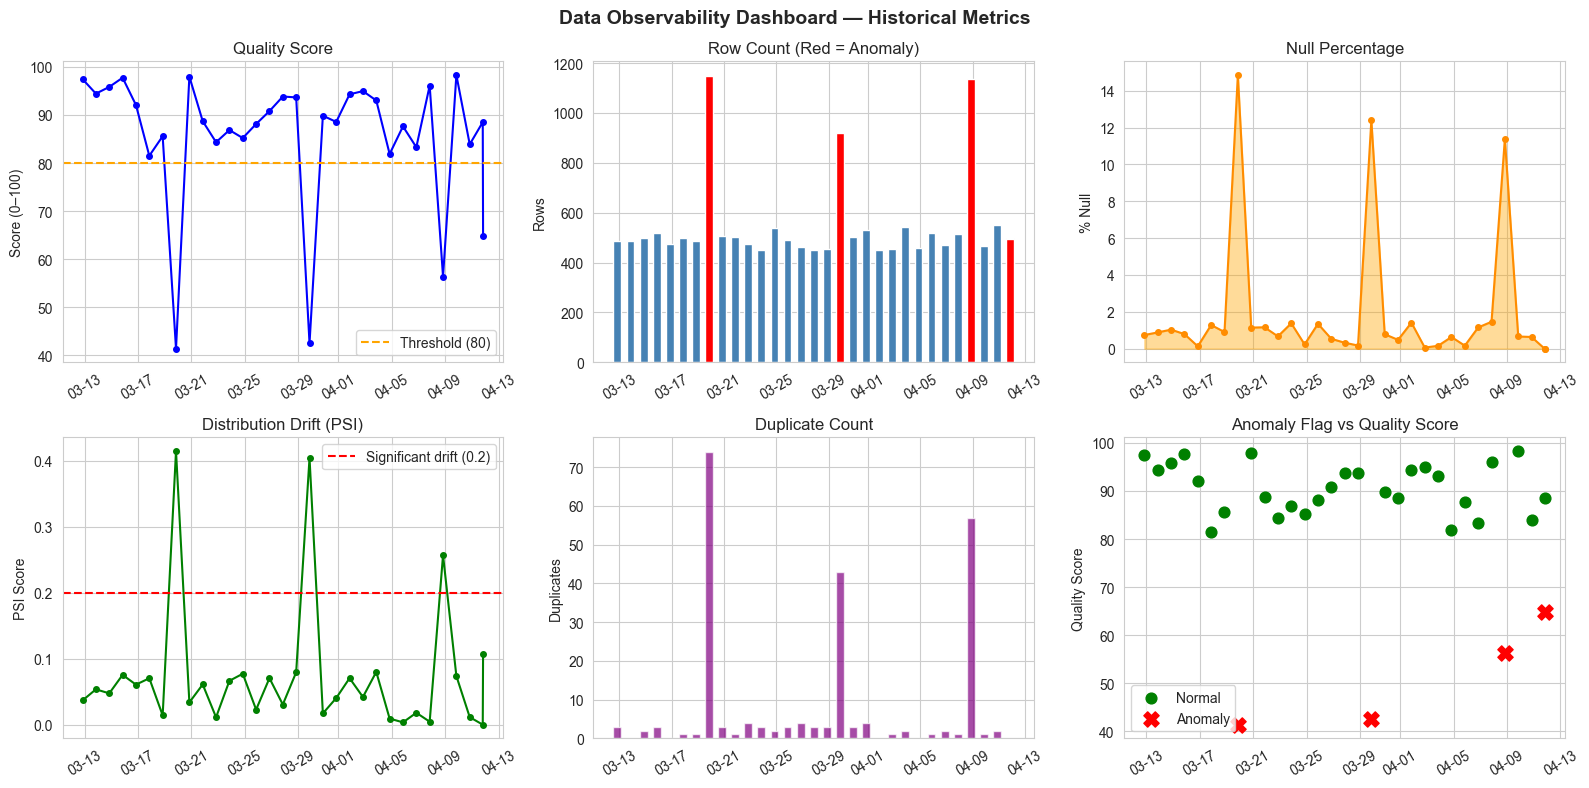

Chart saved to logs/dashboard.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_style('whitegrid')

hist_df = pd.DataFrame(historical)


hist_df['timestamp'] = pd.to_datetime(hist_df['timestamp'])


numeric_cols = ['quality_score', 'null_percentage', 'row_count',
                'drift_score', 'duplicate_count', 'anomaly_flag']
for col in numeric_cols:
    hist_df[col] = pd.to_numeric(hist_df[col], errors='coerce')

hist_df = hist_df.sort_values('timestamp')

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Data Observability Dashboard — Historical Metrics',
             fontsize=14, fontweight='bold')

# 1. Quality Score
ax = axes[0, 0]
ax.plot(hist_df['timestamp'], hist_df['quality_score'], 'b-o', ms=4)
ax.axhline(80, color='orange', linestyle='--', label='Threshold (80)')
ax.set_title('Quality Score')
ax.set_ylabel('Score (0–100)')
ax.legend()

# 2. Row Count
ax = axes[0, 1]
colors = ['red' if a else 'steelblue' for a in hist_df['anomaly_flag']]
ax.bar(hist_df['timestamp'], hist_df['row_count'], color=colors, width=0.6)
ax.set_title('Row Count (Red = Anomaly)')
ax.set_ylabel('Rows')

# 3. Null Percentage
ax = axes[0, 2]
ax.fill_between(hist_df['timestamp'],
                hist_df['null_percentage'].astype(float),
                alpha=0.4, color='orange')
ax.plot(hist_df['timestamp'], hist_df['null_percentage'],
        'o-', color='darkorange', ms=4)
ax.set_title('Null Percentage')
ax.set_ylabel('% Null')

# 4. Drift Score (PSI)
ax = axes[1, 0]
ax.plot(hist_df['timestamp'], hist_df['drift_score'], 'g-o', ms=4)
ax.axhline(0.2, color='red', linestyle='--', label='Significant drift (0.2)')
ax.set_title('Distribution Drift (PSI)')
ax.set_ylabel('PSI Score')
ax.legend()

# 5. Duplicate Count
ax = axes[1, 1]
ax.bar(hist_df['timestamp'], hist_df['duplicate_count'],
       color='purple', alpha=0.7, width=0.6)
ax.set_title('Duplicate Count')
ax.set_ylabel('Duplicates')

# 6. Anomaly Flag vs Quality Score
ax = axes[1, 2]
anomaly_days = hist_df[hist_df['anomaly_flag'] == 1]
normal_days  = hist_df[hist_df['anomaly_flag'] == 0]
ax.scatter(normal_days['timestamp'],  normal_days['quality_score'],
            c='green', label='Normal',  s=60)
ax.scatter(anomaly_days['timestamp'], anomaly_days['quality_score'],
            c='red',   label='Anomaly', s=120, marker='X')
ax.set_title('Anomaly Flag vs Quality Score')
ax.set_ylabel('Quality Score')
ax.legend()

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
os.makedirs(os.path.join(PROJECT_ROOT, 'logs'), exist_ok=True)
plt.savefig(os.path.join(PROJECT_ROOT, 'logs', 'dashboard.png'),
             dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to logs/dashboard.png')

## 🔄 CELL 11 — Run Full Pipeline for ALL 10 Snapshots
> Populates MySQL with 10 rows of metrics — good for Power BI visualisation.

In [15]:
import glob

snapshot_files = sorted(glob.glob(os.path.join(SNAPSHOTS_DIR, 'snapshot_*.csv')))
print(f'Processing {len(snapshot_files)} snapshots...')

all_results = []

for i, snap_path in enumerate(snapshot_files):
    snap_df = pd.read_csv(snap_path)
    prev_snap_df = pd.read_csv(snapshot_files[i-1]) if i > 0 else None

    results   = run_all_checks(snap_df, prev_snap_df)
    m         = extract_metrics(snap_df, results)

   
    snap_date = os.path.basename(snap_path).replace('snapshot_','').replace('.csv','')
    m['timestamp'] = snap_date + ' 08:00:00'

    row_id = db_manager.insert_metrics(m)
    all_results.append(m)
    print(f'  Day {i+1:02d} | {snap_date} | score={m["quality_score"]} | anomaly={m["anomaly_flag"]} | row_id={row_id}')

print(f'\n✅ Inserted {len(all_results)} rows into metrics_history.')

2026-04-11 20:28:52,636 | INFO | Quality checks complete: 16/21 passed
2026-04-11 20:28:52,637 | INFO | Metrics generated | score=80.7 | anomaly=1 | drift=0.0 | checks=16/21
2026-04-11 20:28:52,645 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:28:52,648 | INFO | Inserted metrics row id=3 | score=80.7
2026-04-11 20:28:52,678 | INFO | Quality checks complete: 16/21 passed
2026-04-11 20:28:52,679 | INFO | Metrics generated | score=80.7 | anomaly=1 | drift=0.0695 | checks=16/21
2026-04-11 20:28:52,684 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:28:52,688 | INFO | Inserted metrics row id=4 | score=80.7
2026-04-11 20:28:52,721 | INFO | Quality checks complete: 15/21 passed
2026-04-11 20:28:52,722 | INFO | Metrics generated | score=75.44 | anomaly=1 | drift=0.0383 | checks=15/21
2026-04-11 20:28:52,727 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:28:52,730 | INFO | Inserted metrics row id=5 | score=75.44
2026-04-11 20:28:52,761 | INFO | Quality checks

Processing 10 snapshots...
  Day 01 | 2026-04-01 | score=80.7 | anomaly=1 | row_id=3
  Day 02 | 2026-04-02 | score=80.7 | anomaly=1 | row_id=4
  Day 03 | 2026-04-03 | score=75.44 | anomaly=1 | row_id=5
  Day 04 | 2026-04-04 | score=80.7 | anomaly=1 | row_id=6


2026-04-11 20:28:52,811 | INFO | Quality checks complete: 16/21 passed
2026-04-11 20:28:52,812 | INFO | Metrics generated | score=80.7 | anomaly=1 | drift=0.0737 | checks=16/21
2026-04-11 20:28:52,816 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:28:52,819 | INFO | Inserted metrics row id=7 | score=80.7
2026-04-11 20:28:52,851 | INFO | Quality checks complete: 16/21 passed
2026-04-11 20:28:52,852 | INFO | Metrics generated | score=80.7 | anomaly=1 | drift=0.0799 | checks=16/21
2026-04-11 20:28:52,857 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:28:52,860 | INFO | Inserted metrics row id=8 | score=80.7
2026-04-11 20:28:52,896 | INFO | Quality checks complete: 14/21 passed
2026-04-11 20:28:52,896 | INFO | Metrics generated | score=65.79 | anomaly=1 | drift=0.0386 | checks=14/21
2026-04-11 20:28:52,900 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:28:52,904 | INFO | Inserted metrics row id=9 | score=65.79
2026-04-11 20:28:52,937 | INFO | Quality che

  Day 05 | 2026-04-05 | score=80.7 | anomaly=1 | row_id=7
  Day 06 | 2026-04-06 | score=80.7 | anomaly=1 | row_id=8
  Day 07 | 2026-04-07 | score=65.79 | anomaly=1 | row_id=9
  Day 08 | 2026-04-08 | score=75.44 | anomaly=1 | row_id=10
  Day 09 | 2026-04-09 | score=55.26 | anomaly=1 | row_id=11


2026-04-11 20:28:53,009 | INFO | Metrics generated | score=64.91 | anomaly=1 | drift=0.1076 | checks=12/21
2026-04-11 20:28:53,014 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:28:53,018 | INFO | Inserted metrics row id=12 | score=64.91


  Day 10 | 2026-04-10 | score=64.91 | anomaly=1 | row_id=12

✅ Inserted 10 rows into metrics_history.


## 🕐 CELL 12 — APScheduler (Run Pipeline Daily)
> Run this in a separate terminal: `python scheduler/pipeline_scheduler.py --run-now`
> Or schedule: `python scheduler/pipeline_scheduler.py --hour 8 --minute 0`

In [16]:


import importlib
import scheduler.pipeline_scheduler as sched_module

print('Running one pipeline iteration now...')
result = sched_module.run_pipeline()

print(f'\n  Status    : {result["status"]}')
print(f'  Started   : {result["started_at"]}')
print(f'  Finished  : {result["finished_at"]}')
if result['metrics']:
    print(f'  Score     : {result["metrics"]["quality_score"]}')
    print(f'  Anomaly   : {result["metrics"]["anomaly_flag"]}')
if result['error']:
    print(f'  Error     : {result["error"]}')

2026-04-11 20:29:00 | scheduler       | INFO     | ============================================================
2026-04-11 20:29:00,983 | INFO | ============================================================
2026-04-11 20:29:00 | scheduler       | INFO     | PIPELINE START  →  2026-04-11 20:29:00
2026-04-11 20:29:00,984 | INFO | PIPELINE START  →  2026-04-11 20:29:00
2026-04-11 20:29:00 | scheduler       | INFO     | ============================================================
2026-04-11 20:29:00,985 | INFO | ============================================================
2026-04-11 20:29:00 | scheduler       | INFO     | STEP 1 → Loading latest snapshot...
2026-04-11 20:29:00,985 | INFO | STEP 1 → Loading latest snapshot...
2026-04-11 20:29:00,986 | INFO | Loading latest snapshot: E:\data science\pooject\data_observability_project\data_observability\data\snapshots\snapshot_2026-04-10.csv
2026-04-11 20:29:00,990 | INFO | Loaded 'E:\data science\pooject\data_observability_project\data_observ

Running one pipeline iteration now...

   DATA QUALITY METRICS SUMMARY
  Dataset       : ecommerce_sales
  Timestamp     : 2026-04-11 20:29:01
  Row Count     : 493
  Null %        : 0.00%
  Duplicates    : 0
  Outliers(IQR) : 43
  Volume Δ %    : 10.85%
  Drift Score   : 0.1076
  Correlation Δ : 1.8338
  Entropy Δ     : 0.0148
  Skewness(max) : 6.7884
  Checks        : 12/21 passed
  Anomaly Flag  : 🚨 YES
  Quality Score : [████████████░░░░░░░░] 64.9/100  Grade: C



2026-04-11 20:29:01,199 | INFO | Chain [1] done processing
2026-04-11 20:29:01,231 | INFO | Prophet forecast complete. Anomalies in history: 1
2026-04-11 20:29:01 | scheduler       | INFO     |   IsolationForest: ANOMALY | score=0.7212
2026-04-11 20:29:01,232 | INFO |   IsolationForest: ANOMALY | score=0.7212
2026-04-11 20:29:01 | scheduler       | INFO     | STEP 6 → Logging summary...
2026-04-11 20:29:01,233 | INFO | STEP 6 → Logging summary...
2026-04-11 20:29:01 | scheduler       | WARNING  | 🚨 ANOMALY DETECTED  | score=64.91 | ml_score=0.7212
2026-04-11 20:29:01,234 | WARNING | 🚨 ANOMALY DETECTED  | score=64.91 | ml_score=0.7212
2026-04-11 20:29:01 | scheduler       | INFO     | PIPELINE END  →  elapsed=0.25s  status=success
2026-04-11 20:29:01,235 | INFO | PIPELINE END  →  elapsed=0.25s  status=success
2026-04-11 20:29:01 | scheduler       | INFO     | ============================================================
2026-04-11 20:29:01,236 | INFO | ===================================


  Status    : success
  Started   : 2026-04-11T20:29:00.983968
  Finished  : 2026-04-11T20:29:01.235582
  Score     : 64.91
  Anomaly   : 1


## 📊 CELL 13 — Power BI SQL Queries
> Copy these queries into Power BI → Get Data → MySQL

In [17]:
powerbi_queries = {

    '1_quality_score_trend': '''
SELECT
    DATE(timestamp)   AS report_date,
    quality_score,
    anomaly_flag,
    drift_score
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY report_date;
''',

    '2_null_pct_trend': '''
SELECT
    DATE(timestamp)  AS report_date,
    null_percentage,
    duplicate_count
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY report_date;
''',

    '3_row_count_changes': '''
SELECT
    DATE(timestamp)         AS report_date,
    row_count,
    volume_change_pct,
    CASE WHEN anomaly_flag = 1 THEN 'Anomaly' ELSE 'Normal' END AS status
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY report_date;
''',

    '4_anomaly_summary': '''
SELECT
    DATE(timestamp)  AS report_date,
    quality_score,
    anomaly_flag,
    drift_score,
    null_percentage,
    outlier_count,
    duplicate_count
FROM metrics_history
WHERE anomaly_flag = 1
  AND dataset_name = 'ecommerce_sales'
ORDER BY report_date;
''',

    '5_drift_indicators': '''
SELECT
    DATE(timestamp)   AS report_date,
    drift_score,
    correlation_drift,
    entropy_delta,
    max_skewness,
    CASE
        WHEN drift_score < 0.1  THEN 'No Drift'
        WHEN drift_score < 0.2  THEN 'Slight Drift'
        ELSE                         'Significant Drift'
    END AS drift_level
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY report_date;
''',

    '6_kpi_summary_today': '''
SELECT
    quality_score,
    anomaly_flag,
    row_count,
    null_percentage,
    duplicate_count,
    drift_score,
    checks_passed,
    total_checks
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY timestamp DESC
LIMIT 1;
'''
}

for name, sql in powerbi_queries.items():
    print(f'\n── Query: {name} ──────────────────────────────')
    print(sql)


── Query: 1_quality_score_trend ──────────────────────────────

SELECT
    DATE(timestamp)   AS report_date,
    quality_score,
    anomaly_flag,
    drift_score
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY report_date;


── Query: 2_null_pct_trend ──────────────────────────────

SELECT
    DATE(timestamp)  AS report_date,
    null_percentage,
    duplicate_count
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY report_date;


── Query: 3_row_count_changes ──────────────────────────────

SELECT
    DATE(timestamp)         AS report_date,
    row_count,
    volume_change_pct,
    CASE WHEN anomaly_flag = 1 THEN 'Anomaly' ELSE 'Normal' END AS status
FROM metrics_history
WHERE dataset_name = 'ecommerce_sales'
ORDER BY report_date;


── Query: 4_anomaly_summary ──────────────────────────────

SELECT
    DATE(timestamp)  AS report_date,
    quality_score,
    anomaly_flag,
    drift_score,
    null_percentage,
    outlier_count,
    duplicate_coun

## ✅ CELL 14 — Project Summary


In [18]:
all_metrics = db_manager.fetch_all_metrics()
summary_df  = pd.DataFrame(all_metrics)

if not summary_df.empty:
    print('='*60)
    print('   PROJECT SUMMARY')
    print('='*60)
    print(f'  Total pipeline runs  : {len(summary_df)}')
    print(f'  Avg quality score    : {summary_df["quality_score"].mean():.2f}')
    print(f'  Anomalies detected   : {summary_df["anomaly_flag"].sum()}')
    print(f'  Avg null percentage  : {summary_df["null_percentage"].mean():.4f}%')
    print(f'  Avg drift score      : {summary_df["drift_score"].mean():.4f}')
    print(f'  Max row count        : {summary_df["row_count"].max():,}')
    print(f'  Min row count        : {summary_df["row_count"].min():,}')
    print('='*60)
    display(summary_df[['timestamp','quality_score','anomaly_flag',
                         'null_percentage','drift_score','row_count']].tail(10))

2026-04-11 20:29:12,240 | INFO | Connected to MySQL @ localhost:3306
2026-04-11 20:29:12,241 | INFO | Fetched 13 metric rows.


   PROJECT SUMMARY
  Total pipeline runs  : 13
  Avg quality score    : 73.74
  Anomalies detected   : 12
  Avg null percentage  : 0.0554%
  Avg drift score      : 0.0561
  Max row count        : 864
  Min row count        : 405


,timestamp,quality_score,anomaly_flag,null_percentage,drift_score,row_count
3,2026-04-04 08:00:00,80.70,1,0.0000,0.0218,463
4,2026-04-05 08:00:00,80.70,1,0.0000,0.0737,416
5,2026-04-06 08:00:00,80.70,1,0.0000,0.0799,434
6,2026-04-07 08:00:00,65.79,1,0.0000,0.0386,864
7,2026-04-08 08:00:00,75.44,1,0.0000,0.0344,438
8,2026-04-09 08:00:00,55.26,1,0.7200,0.0508,553
9,2026-04-10 08:00:00,64.91,1,0.0000,0.1076,493
10,2026-04-11 19:41:24,88.50,0,0.0000,0.0000,500
11,2026-04-11 20:16:39,64.91,1,0.0000,0.1076,493
12,2026-04-11 20:29:01,64.91,1,0.0000,0.1076,493
